In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('PlayTennis.csv')
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [3]:
x=df.drop('play',axis=1)
x=pd.get_dummies(x)
y=df['play']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
df=DecisionTreeClassifier(criterion='entropy',random_state=42)
df.fit(x_train,y_train)
y_pred=df.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [4]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
RF=RandomForestClassifier(criterion='entropy',random_state=42,n_estimators=51)
RF.fit(x_train,y_train)
y_pred=RF.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

AttributeError: 'DecisionTreeClassifier' object has no attribute 'drop'

In [ ]:
df=pd.read_csv('titanic.csv')
df 

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [ ]:
df=df.drop(['cabin','ticket','name'],axis=1)

In [ ]:
df.embarked=df.embarked.fillna(df.embarked.mode()[0])

In [ ]:
df=df.fillna(df.mean(numeric_only=True))

In [ ]:
y=df['survived']
x = df.drop('survived',axis=1)
x=pd.get_dummies(x)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_knn=0
for i in range(27,45):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_knn:
        ac_knn=ac
        neighbor=i
print(ac,">",neighbor)

0.6526717557251909 > 39


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_dt=0
for i in range(1,50):
    DT=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=i)
    DT.fit(x_train,y_train)
    y_pred=DT.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac_dt,">",i)

0.7786259541984732 > 49


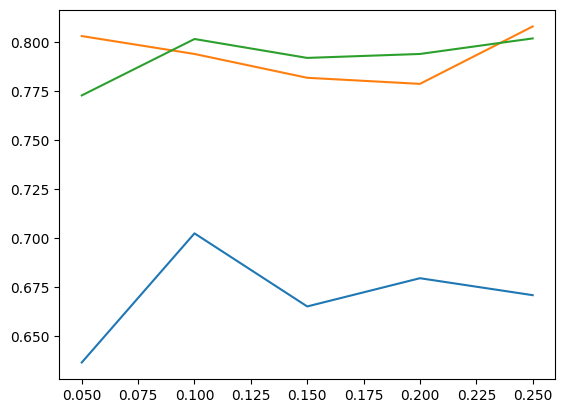

In [ ]:
ac_knn=[]
ac_dt=[]
ac_rf=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=i,random_state=42)
    knn= KNeighborsClassifier(n_neighbors=39)
    knn.fit(x_train, y_train)
    y_pred= knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test, y_pred))

    dt= DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
    dt.fit(x_train, y_train)
    y_pred= dt.predict(x_test)
    ac_dt.append(accuracy_score(y_test, y_pred))

    rf= RandomForestClassifier(criterion='entropy', random_state=42, n_estimators=45)
    rf.fit(x_train, y_train)
    y_pred= rf.predict(x_test)
    ac_rf.append(accuracy_score(y_pred, y_test))

plt.plot(test,ac_knn)
plt.plot(test, ac_dt)
plt.plot(test, ac_rf)